In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('Iris.csv')

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df = df.iloc[:,1:]
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
from sklearn.preprocessing import LabelEncoder

In [6]:
encoder = LabelEncoder()

In [7]:
df["Species"] = encoder.fit_transform(df["Species"])

In [8]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [9]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


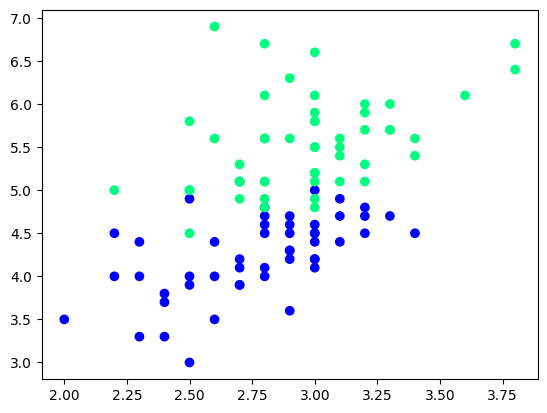

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap='winter')

In [11]:
df_train = df.iloc[:60,:].sample(10)
df_train

,SepalWidthCm,PetalLengthCm,Species
71,2.8,4.0,1
60,2.0,3.5,1
69,2.5,3.9,1
82,2.7,3.9,1
84,3.0,4.5,1
77,3.0,5.0,1
58,2.9,4.6,1
102,3.0,5.9,2
79,2.6,3.5,1
68,2.2,4.5,1


In [12]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [13]:
df_train

,SepalWidthCm,PetalLengthCm,Species
123,2.7,4.9,2
81,2.4,3.7,1
112,3.0,5.5,2
93,2.3,3.3,1
98,2.5,3.0,1
107,2.9,6.3,2
109,3.6,6.1,2
95,3.0,4.2,1
103,2.9,5.6,2
147,3.0,5.2,2


In [14]:
df_test

,SepalWidthCm,PetalLengthCm,Species
91,3.0,4.6,1
130,2.8,6.1,2
71,2.8,4.0,1
108,2.5,5.8,2
124,3.3,5.7,2


In [15]:
df_val

,SepalWidthCm,PetalLengthCm,Species
54,2.8,4.6,1
77,3.0,5.0,1
73,2.8,4.7,1
120,3.2,5.7,2
115,3.2,5.3,2


In [16]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [17]:
y_test

array([1, 1, 1, 2, 2])

In [18]:
# Case 1 - Bagging
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
123,2.7,4.9,2
107,2.9,6.3,2
95,3.0,4.2,1
81,2.4,3.7,1
93,2.3,3.3,1
81,2.4,3.7,1
81,2.4,3.7,1
112,3.0,5.5,2


In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [25]:
dt_bag1 = DecisionTreeClassifier()

In [26]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

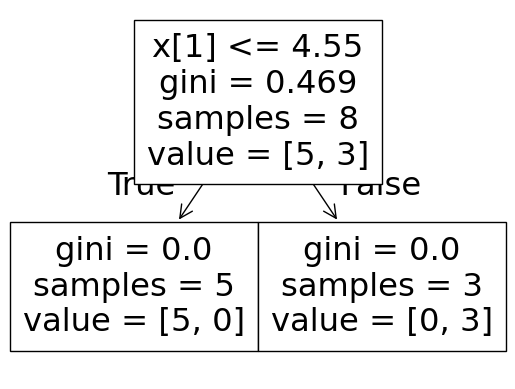

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.4


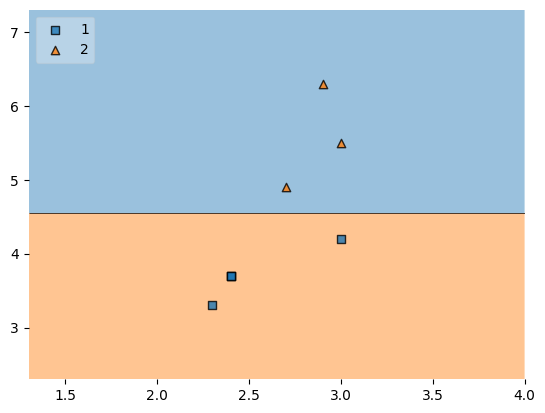

In [27]:
evaluate(dt_bag1,X,y)

In [28]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
98,2.5,3.0,1
112,3.0,5.5,2
109,3.6,6.1,2
123,2.7,4.9,2
81,2.4,3.7,1
93,2.3,3.3,1
93,2.3,3.3,1
95,3.0,4.2,1


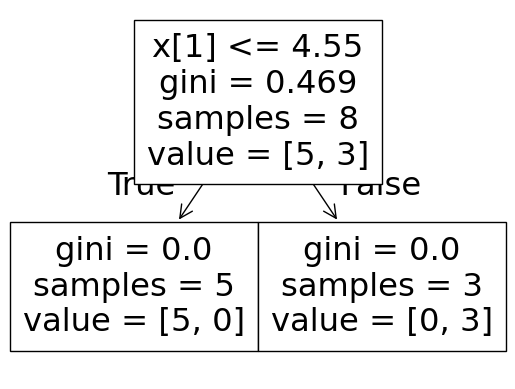

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.4


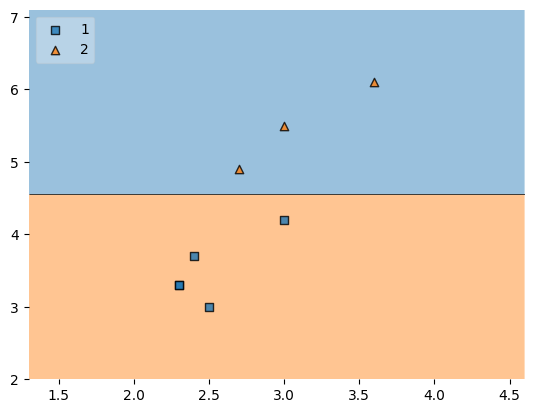

In [29]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [30]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
98,2.5,3.0,1
98,2.5,3.0,1
123,2.7,4.9,2
107,2.9,6.3,2
95,3.0,4.2,1
95,3.0,4.2,1
147,3.0,5.2,2
103,2.9,5.6,2


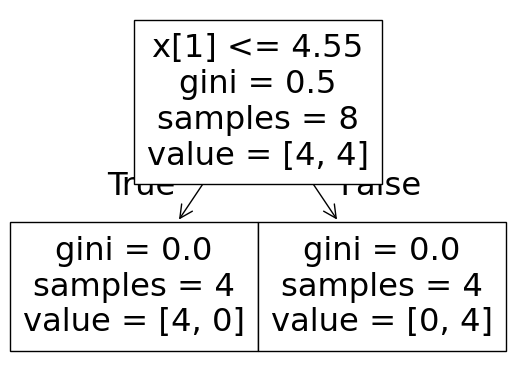

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.4


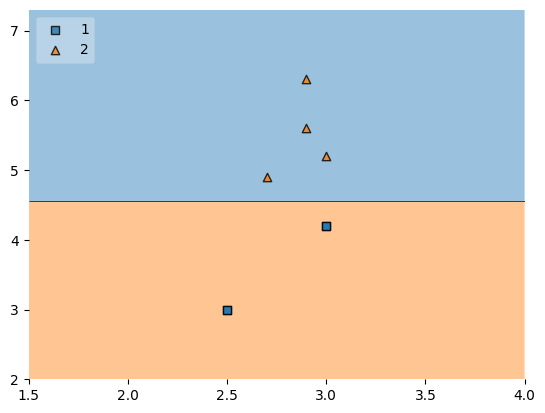

In [31]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [32]:
# Predict
df_test

,SepalWidthCm,PetalLengthCm,Species
91,3.0,4.6,1
130,2.8,6.1,2
71,2.8,4.0,1
108,2.5,5.8,2
124,3.3,5.7,2


In [33]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [34]:
# Pasting
# Row sampling without replacement
df_train

,SepalWidthCm,PetalLengthCm,Species
123,2.7,4.9,2
81,2.4,3.7,1
112,3.0,5.5,2
93,2.3,3.3,1
98,2.5,3.0,1
107,2.9,6.3,2
109,3.6,6.1,2
95,3.0,4.2,1
103,2.9,5.6,2
147,3.0,5.2,2


In [35]:
df_train.sample(8)

,SepalWidthCm,PetalLengthCm,Species
103,2.9,5.6,2
123,2.7,4.9,2
81,2.4,3.7,1
98,2.5,3.0,1
107,2.9,6.3,2
95,3.0,4.2,1
93,2.3,3.3,1
109,3.6,6.1,2


In [36]:
# Random Subspaces
df1 = pd.read_csv('Iris.csv')
df1 = df1.sample(10)
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
139,140,6.9,3.1,5.4,2.1,Iris-virginica
124,125,6.7,3.3,5.7,2.1,Iris-virginica
91,92,6.1,3.0,4.6,1.4,Iris-versicolor
137,138,6.4,3.1,5.5,1.8,Iris-virginica
85,86,6.0,3.4,4.5,1.6,Iris-versicolor
83,84,6.0,2.7,5.1,1.6,Iris-versicolor
11,12,4.8,3.4,1.6,0.2,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
23,24,5.1,3.3,1.7,0.5,Iris-setosa
134,135,6.1,2.6,5.6,1.4,Iris-virginica


In [37]:
df1.sample(2,replace=True,axis=1)

,PetalWidthCm,SepalLengthCm
139,2.1,6.9
124,2.1,6.7
91,1.4,6.1
137,1.8,6.4
85,1.6,6.0
83,1.6,6.0
11,0.2,4.8
6,0.3,4.6
23,0.5,5.1
134,1.4,6.1


In [38]:
# Random Patches
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
139,140,6.9,3.1,5.4,2.1,Iris-virginica
124,125,6.7,3.3,5.7,2.1,Iris-virginica
91,92,6.1,3.0,4.6,1.4,Iris-versicolor
137,138,6.4,3.1,5.5,1.8,Iris-virginica
85,86,6.0,3.4,4.5,1.6,Iris-versicolor
83,84,6.0,2.7,5.1,1.6,Iris-versicolor
11,12,4.8,3.4,1.6,0.2,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
23,24,5.1,3.3,1.7,0.5,Iris-setosa
134,135,6.1,2.6,5.6,1.4,Iris-virginica


In [39]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,SepalLengthCm,SepalLengthCm
124,6.7,6.7
11,4.8,4.8
137,6.4,6.4
139,6.9,6.9
85,6.0,6.0
85,6.0,6.0
91,6.1,6.1
23,5.1,5.1
